# Buổi 9 — Đặc trưng chuỗi và khả năng dự báo

**Một câu:** tóm mỗi chuỗi thành một hàng số (đặc trưng) để xếp hạng, lọc và nhóm hàng nghìn chuỗi — và kiểm cẩn thận thước đo
trước khi nói "đặc trưng này đoán được độ khó".

Tình huống: bạn nhận 4.000 chuỗi doanh số, sản lượng theo tháng (lấy từ cuộc thi M4) và thời gian chỉ đủ tune kỹ một phần. Chuỗi nào
đáng đầu tư mô hình, chuỗi nào dùng baseline là đủ? Chuỗi nào hỏng? Chuỗi nào giống nhau?

| Phần | Câu hỏi |
|---|---|
| 1 | Tóm một chuỗi thành những con số nào để so được với chuỗi khác? |
| 2 | Một con số nào nói chuỗi giống nhiễu tới đâu? |
| 3 | Vì sao đo độ khó bằng MASE lại kết luận "entropy vô dụng"? |
| 4 | Vẽ 4.000 chuỗi trên một hình thế nào, và chuỗi nào dùng baseline? |
| 5 | Gom chuỗi theo hình dạng: vì sao phải chuẩn hoá trước? |
| 6 | Bảng ABC–XYZ nói được gì, và không nói được gì? |

## 0. Dữ liệu

**Bộ dữ liệu M4 Monthly (Monash Time Series Forecasting Archive).** **48.000 chuỗi theo tháng** của cuộc thi dự báo M4 (2018): doanh số, sản lượng, chỉ số kinh tế, dân số… của sáu
lĩnh vực (vi mô, vĩ mô, công nghiệp, tài chính, nhân khẩu, khác), dài từ 60 tới 2.812 tháng. Nhóm Monash gói lại thành một
tệp `.tsf`: vài dòng đầu bắt đầu bằng `#` hoặc `@` là mô tả, sau dòng `@data` mỗi dòng là **một chuỗi**. Chuỗi đã bị ẩn
danh: không biết chuỗi nào là của công ty hay ngành nào.

Nguồn: Godahewa et al. (2021). Monash Time Series Forecasting Archive. NeurIPS Datasets and Benchmarks Track. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `tên chuỗi` | mã như `T1`, `T2`… — phần trước dấu `:` đầu tiên |
| `mốc bắt đầu` | ngày của tháng đầu tiên — phần giữa hai dấu `:` |
| `giá trị` | các số của chuỗi theo thứ tự thời gian, cách nhau bằng dấu phẩy |

**Bộ dữ liệu Online Retail II.** Mọi **dòng hoá đơn** của một cửa hàng bán quà tặng trực tuyến ở Anh từ 1/12/2009 tới 9/12/2011, khách chủ yếu là
cửa hàng bán buôn — 1.067.371 dòng. Tệp Excel có hai trang tính (`Year 2009-2010`, `Year 2010-2011`), mỗi dòng là **một
mã hàng trên một hoá đơn**. Hoá đơn huỷ có số bắt đầu bằng `C` và số lượng âm.

Nguồn: Chen, D. (2012). Online Retail II [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5CG6D. Giấy phép CC BY 4.0.

| Cột | Nghĩa |
|---|---|
| `Invoice` | số hoá đơn; bắt đầu bằng `C` là hoá đơn huỷ |
| `StockCode` | mã hàng |
| `Quantity` | số lượng trên dòng này (âm khi trả hàng) |
| `InvoiceDate` | ngày giờ lập hoá đơn |
| `Price` | đơn giá, bảng Anh (£) |
| `Customer ID`, `Country` | mã khách (nhiều dòng để trống) và nước của khách |

Ô dưới tải dữ liệu (74 MB) một lần rồi kiểm **sha256** — "dấu vân tay" tính từ nội dung tệp, sai một byte là ra chuỗi khác hẳn. Khớp nghĩa là bạn đang có đúng tệp mà mọi con số dưới đây được tính ra.

In [ ]:
import hashlib
import os
import urllib.request
from pathlib import Path

# tên bộ: (sha256, [nơi tải, thử lần lượt])
DU_LIEU = {
    "monash-m4-monthly": ("473aa4fc814b625174be2b5615959f35f85f566fbed09c30acf44c350b2a1efe", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/monash-m4-monthly/m4_monthly_dataset.zip",
        "https://zenodo.org/records/4656480/files/m4_monthly_dataset.zip?download=1",
    ]),
    "uci-online-retail-ii": ("572e36277c2390fbfde10664750731e0a86f55e33470d91919085f0408e67bfb", [
        "https://huggingface.co/datasets/Tony2202/khoa-forecasting-du-lieu/resolve/105db7d8d51c8ff1229ec06c363f641417124bf3/uci-online-retail-ii/online+retail+ii.zip",
        "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip",
    ]),
}
CACHE = Path(os.environ.get("KHOA_FORECASTING_CACHE") or Path.home() / ".cache" / "khoa-forecasting")


def sha256(tep: Path) -> str:
    h = hashlib.sha256()
    with open(tep, "rb") as f:
        for khoi in iter(lambda: f.read(1 << 20), b""):
            h.update(khoi)
    return h.hexdigest()


def lay(ten: str) -> Path:
    """Đường dẫn tệp đã kiểm sha256; chưa có thì tải về một lần."""
    sha, urls = DU_LIEU[ten]
    tep = CACHE / "sha256" / sha[:2] / sha
    if tep.is_file() and sha256(tep) == sha:
        return tep
    tep.parent.mkdir(parents=True, exist_ok=True)
    for url in urls:
        try:
            urllib.request.urlretrieve(url, tep)
            if sha256(tep) == sha:
                return tep
            print("sha256 không khớp:", url)
        except OSError as loi:
            print("tải lỗi:", url, loi)
    raise RuntimeError(f"không tải được {ten} khớp sha256")


for ten in DU_LIEU:
    print(f"{ten:<28} {lay(ten)}")

In [ ]:
import io
import time
import warnings
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import signal, stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import kpss

M, TAM, DAI = 12, 18, 120      # chu kỳ mùa vụ; 18 tháng chấm; 120 tháng tính đặc trưng


def doc_tsf(tep):
    # .tsf: dòng @/# là mô tả; sau "@data" mỗi dòng là  tên:mốc_bắt_đầu:v1,v2,…
    chuoi, trong_data = {}, False
    with zipfile.ZipFile(tep) as z, z.open("m4_monthly_dataset.tsf") as f:
        for dong in io.TextIOWrapper(f, encoding="utf-8", errors="ignore"):
            if not trong_data:
                trong_data = dong.strip().lower() == "@data"
            elif dong.strip():
                ten, _, gia_tri = dong.strip().split(":", 2)
                chuoi[ten] = np.array(gia_tri.split(","), dtype=float)
    return chuoi


tat_ca = doc_tsf(lay("monash-m4-monthly"))
rng = np.random.default_rng(42)
du_dai = [t for t, v in tat_ca.items() if v.size >= DAI + TAM]
chuoi = {t: tat_ca[t][-(DAI + TAM):] for t in rng.choice(np.array(du_dai), size=4000, replace=False)}
print(f"{len(tat_ca):,} chuỗi M4 tháng | lấy 4.000 chuỗi (seed 42), mỗi chuỗi {DAI + TAM} tháng cuối")

## 1. Mỗi chuỗi thành 20 con số; chỉ 2 con số đổi theo đơn vị

**Vấn đề.** 4.000 chuỗi thì không ai xem từng hình. Muốn hỏi "chuỗi nào khó, chuỗi nào giống nhau, chuỗi nào hỏng" thì cần tóm mỗi
chuỗi thành vài con số so được với nhau — kể cả giữa công ty bán trăm sản phẩm và công ty bán trăm nghìn.

> **đặc trưng (feature) của chuỗi** · *time series feature*
>
> - **Là gì:** một con số tóm một tính chất của **cả** chuỗi: dao động to không, có mùa vụ không, có vài tháng cực đoan không.
> - **Ví dụ:** chuỗi 2, 4, 6, 4, 2, 4, 6, 4 có CV = 0,378 và $r_1$ = 0.
> - **Để làm gì:** biến mỗi chuỗi thành một hàng số, để lọc, xếp hạng, nhóm hàng nghìn chuỗi mà không phải xem từng hình.

> **hệ số lệch (skewness)** · *skewness*
>
> - **Là gì:** đo phân phối lệch về một phía: dương là có vài giá trị rất lớn (đuôi phải dài), âm là vài giá trị rất nhỏ.
> - **Ví dụ:** 1, 1, 2, 2, 3, 20 → hệ số lệch 1,75: một số 20 kéo đuôi phải.
> - **Để làm gì:** báo chuỗi có vài tháng tăng vọt — những tháng mà trung bình và MAE bị kéo theo.
>
> 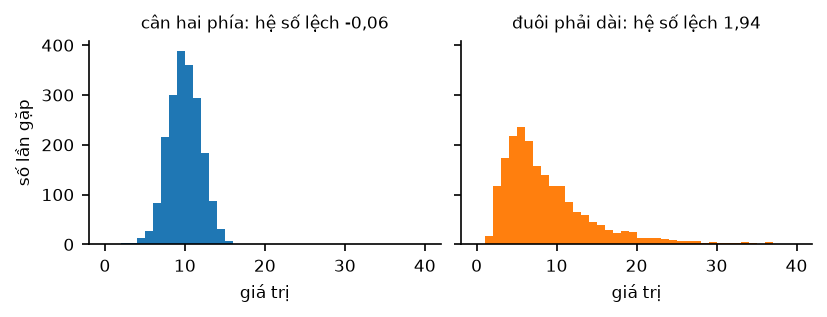

> **độ nhọn (kurtosis)** · *excess kurtosis*
>
> - **Là gì:** đo giá trị cực đoan hay gặp cỡ nào so với phân phối chuẩn (hình chuông); bằng 0 là như chuẩn, dương là hay gặp hơn.
> - **Ví dụ:** chuỗi phần lớn quanh 100 nhưng có ba tháng 400 → độ nhọn dương lớn.
> - **Để làm gì:** cảnh báo sai số dự báo sẽ có vài lần rất lớn, dù trung bình trông ổn.

> **z-score (chuẩn hoá)** · *z-score standardization*
>
> - **Là gì:** trừ trung bình rồi chia độ lệch chuẩn: bỏ mức và biên độ, chỉ giữ hình dạng.
> - **Ví dụ:** 100, 300, 100, 300 → −1, 1, −1, 1; và 1, 3, 1, 3 cũng ra −1, 1, −1, 1.
> - **Để làm gì:** so hình dạng của các chuỗi khác cỡ; tính đặc trưng không đổi theo đơn vị.
>
> 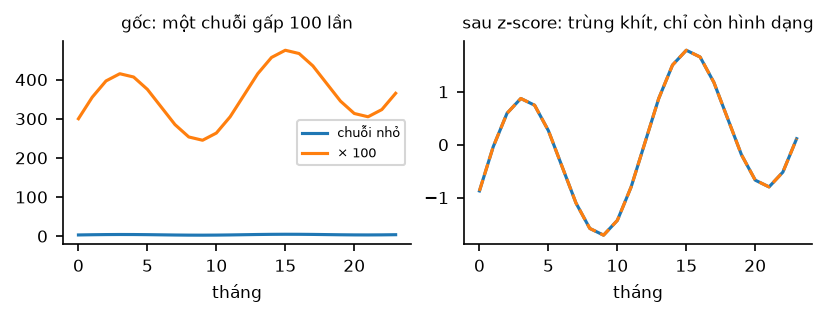

> **catch22** · *CAnonical Time-series CHaracteristics*
>
> - **Là gì:** bộ 22 đặc trưng mà nhóm Lubba chọn lọc từ 4.791 đặc trưng, bỏ cái kém và cái trùng nhau.
> - **Ví dụ:** một đặc trưng của nó: đoạn dài nhất liên tiếp nằm trên trung bình; 1, 5, 6, 7, 5, 1, 1, 2 → 4.
> - **Để làm gì:** bộ đặc trưng gọn, dùng chung trong nghiên cứu; nhắc rằng nhiều đặc trưng không có nghĩa là nhiều thông tin.

> **nhu cầu gián đoạn (intermittent demand)** · *intermittent demand*
>
> - **Là gì:** chuỗi có nhiều kỳ bằng 0, thỉnh thoảng mới có một số dương.
> - **Ví dụ:** 0, 0, 3, 0, 0, 1: tỷ lệ số 0 là 4/6 ≈ 0,67.
> - **Để làm gì:** cần mô hình riêng; đặc trưng "tỷ lệ số 0" lọc ra chúng.

**Lý do.** Đặc trưng tốt **không đổi khi nhân chuỗi với một số**: CV (độ lệch chuẩn / trung bình), $r_1$ (tử và mẫu cùng nhân 1.000²),
tỷ lệ số 0… Chỉ trung bình và độ lệch chuẩn đổi — chúng chỉ nói công ty to hay nhỏ. Nhóm đặc trưng STL (xu hướng, mùa vụ) tính trên
chuỗi đã z-score, nếu không độ dốc sẽ tính bằng USD mỗi tháng. Và mọi chuỗi được cắt về cùng 120 tháng trước khi tính.

**Kết quả.** Hai mươi đặc trưng:

In [ ]:
def acf(y, tre):
    lech = y - y.mean()
    mau = np.sum(lech**2)
    return float(np.sum(lech[tre:] * lech[:-tre]) / mau) if mau > 0 and tre < y.size else 0.0


def kpss_p(y):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        try:
            return float(kpss(y, regression="c", nlags="auto", result_object=True).pvalue)
        except (ValueError, OverflowError):      # chuỗi hằng làm KPSS vỡ
            return np.nan


def entropy_pho(y):
    _, P = signal.welch(y - y.mean(), fs=1.0, nperseg=min(256, y.size))
    P = P[1:]                                     # bỏ tần số 0 (chỉ là mức trung bình)
    if P.sum() <= 0:
        return 0.0
    p = P / P.sum()
    return float(-np.sum(p * np.log(p + 1e-300)) / np.log(p.size))


def dac_trung(y, m=M):
    y = np.asarray(y, float)
    sd = np.std(y)
    z = (y - y.mean()) / sd if sd > 0 else y - y.mean()
    kq = STL(pd.Series(z, index=pd.period_range("2000-01", periods=y.size, freq="M").to_timestamp()), period=m).fit()
    r, t, s = kq.resid.to_numpy(), kq.trend.to_numpy(), kq.seasonal.to_numpy()
    xu_huong = np.polyfit(np.arange(y.size), t, 2)
    return {
        "trung_binh": y.mean(), "do_lech_chuan": np.std(y, ddof=1),
        "he_so_bien_thien": np.std(y, ddof=1) / y.mean() if y.mean() != 0 else np.nan,
        "he_so_lech": stats.skew(y), "do_nhon": stats.kurtosis(y),
        "acf1": acf(y, 1), "acf10": sum(acf(y, k) ** 2 for k in range(1, 11)), "acf_mua_vu": acf(y, m),
        "diff1_acf1": acf(np.diff(y), 1), "entropy_pho": entropy_pho(y),
        "do_manh_xu_huong": max(0.0, 1 - np.var(r) / np.var(t + r)), "do_manh_mua_vu": max(0.0, 1 - np.var(r) / np.var(s + r)),
        "spike": np.var([np.var(np.delete(r, i)) for i in range(0, r.size, max(1, r.size // 50))]),
        "do_doc_xu_huong": xu_huong[1], "do_cong_xu_huong": xu_huong[0],
        "ty_le_0": np.mean(y == 0),
        "so_lan_cat_trung_binh": np.sum(np.diff((y > y.mean()).astype(int)) != 0),
        "doan_phang": np.max(np.bincount(np.digitize(y, np.histogram_bin_edges(y, bins=10)[1:-1]))) / y.size,
        "bat_on_dinh": np.var([c.mean() for c in np.array_split(y, 10)]) / (np.var(y) + 1e-12),
        "kpss_p": kpss_p(y),
    }


a = np.array([2, 4, 6, 4, 2, 4, 6, 4], float)
print("ví dụ tay: CV", round(np.std(a, ddof=1) / a.mean(), 3), round(np.std(1000 * a, ddof=1) / (1000 * a).mean(), 3),
      "| r1", round(acf(a, 1), 3), round(acf(1000 * a, 1), 3), "| hệ số lệch 1,1,2,2,3,20:", round(stats.skew([1, 1, 2, 2, 3, 20]), 2))

y = next(iter(chuoi.values()))[:DAI]
so = pd.DataFrame({"gốc": dac_trung(y), "× 1.000": dac_trung(1000 * y)})
print("đặc trưng đổi khi nhân 1.000:", list(so.index[~np.isclose(so["gốc"], so["× 1.000"], rtol=1e-6, equal_nan=True)]))

t0 = time.time()
warnings.simplefilter("ignore", RuntimeWarning)                   # chuỗi hằng: 0/0 trong vài đặc trưng
bang = pd.DataFrame({t: dac_trung(v[:-TAM]) for t, v in chuoi.items()}).T.astype(float)   # chỉ phần học, bỏ 18 tháng chấm
print(f"20 đặc trưng × {len(bang):,} chuỗi trong {time.time() - t0:.0f} giây")
print("chuỗi hằng (KPSS NaN):", int(bang["kpss_p"].isna().sum()), "| chuỗi bậc thang (đoạn phẳng > 0,5):",
      int((bang["doan_phang"] > 0.5).sum()))

Chỉ `trung_binh` và `do_lech_chuan` đổi khi nhân 1.000; 18 đặc trưng còn lại giữ nguyên. Đặc trưng còn là máy dò chuỗi hỏng: 1
chuỗi hằng (KPSS vỡ nên NaN) và 50 chuỗi "bậc thang" (hơn nửa số điểm rơi vào cùng một khoảng giá trị).

Đặc trưng catch22 "đoạn dài nhất liên tiếp trên trung bình" tách được hai chuỗi cùng trung bình, cùng độ lệch chuẩn:

In [ ]:
def doan_dai_nhat_tren_tb(y):
    tren, dai, tot = np.asarray(y) > np.mean(y), 0, 0
    for v in tren:
        dai = dai + 1 if v else 0
        tot = max(tot, dai)
    return tot


for ten, v in (("A", [1, 5, 6, 7, 5, 1, 1, 2]), ("B", [1, 6, 1, 6, 1, 6, 1, 6])):
    print(f"{ten}: trung bình {np.mean(v)}, độ lệch chuẩn {np.std(v, ddof=1):.1f}, đoạn dài nhất trên TB {doan_dai_nhat_tren_tb(v)}")

$A$ có "quán tính" (đang cao thì còn cao, đoạn dài 4), $B$ đổi chiều mỗi bước (đoạn dài 1).

**Bài học.** Dùng đặc trưng không đổi theo đơn vị, tính trên cùng độ dài; trung bình và độ lệch chuẩn chỉ để tham chiếu. Chỉ có vài chuỗi
thì xem hình, đừng tóm.

## 2. Spectral entropy: gần 0 là có nhịp rõ, gần 1 là giống nhiễu

**Vấn đề.** Trước khi dự báo, muốn biết chuỗi có nhịp đều để khai thác hay gần như ngẫu nhiên — bằng một con số từ 0 tới 1.

> **tần số** · *frequency*
>
> - **Là gì:** số vòng lặp mỗi bước thời gian; tần số = 1 / chu kỳ.
> - **Ví dụ:** lặp mỗi 12 tháng → tần số 1/12 ≈ 0,083; lặp mỗi 2 tháng → 0,5.
> - **Để làm gì:** gọi tên các nhịp lặp của chuỗi để đo nhịp nào mạnh.
>
> 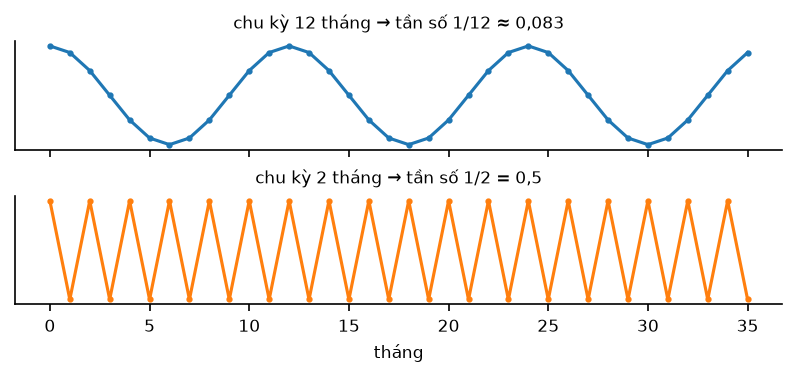

> **phổ, periodogram** · *spectrum, periodogram*
>
> - **Là gì:** mọi chuỗi viết được thành tổng nhiều sóng đều, mỗi sóng một tần số; phổ cho biết mỗi sóng góp bao nhiêu phần vào dao động của chuỗi ("năng lượng"). Cách Welch lấy trung bình phổ của nhiều đoạn chồng nhau cho đỡ nhiễu.
> - **Ví dụ:** chuỗi mùa vụ năm đều đặn dồn gần hết năng lượng vào tần số 1/12; nhiễu thuần chia đều cho mọi tần số.
> - **Để làm gì:** thấy chuỗi có nhịp nào, mạnh cỡ nào — đầu vào của spectral entropy.

> **spectral entropy**
>
> - **Là gì:** đo năng lượng trải đều trên các tần số tới đâu: $H = -\sum p_i \ln p_i / \ln N$, với $p_i$ là phần năng lượng ở tần số $i$, $N$ số tần số. Từ 0 (dồn vào một tần số) tới 1 (trải đều).
> - **Ví dụ:** phần năng lượng 0,5; 0,5; 0; 0 → 0,693 / 1,386 = 0,5.
> - **Để làm gì:** xếp hạng độ khó hàng nghìn chuỗi mà không cần chạy mô hình nào.

> **khả năng dự báo (forecastability)** · *forecastability*
>
> - **Là gì:** chuỗi có bao nhiêu cấu trúc lặp lại mà mô hình khai thác được.
> - **Ví dụ:** doanh số mùa vụ đều dễ dự báo hơn doanh số lên xuống thất thường, dù hai chuỗi cùng mức.
> - **Để làm gì:** biết trước chuỗi nào đáng đầu tư mô hình, chuỗi nào dùng baseline là đủ.

**Lý do.** Chia năng lượng thành các phần cộng lại bằng 1, như chia một chiếc bánh. Cả bánh ở một đĩa thì biết ngay nó ở đâu; chia đều
mọi đĩa thì không đĩa nào nổi bật. Entropy đo "chia đều tới đâu"; chia cho $\ln N$ để luôn nằm trong 0 … 1 bất kể số tần số.

**Kết quả.** Ví dụ tay 4 tần số, hai chuỗi tự tạo, rồi 4.000 chuỗi M4:

In [ ]:
def H(p):
    p = np.asarray(p, float)
    p = p[p > 0]                                   # quy ước 0 × ln 0 = 0
    return -np.sum(p * np.log(p)) / np.log(4)


for ten, p in (("sóng đều", [0, 1, 0, 0]), ("hai nhịp", [0.5, 0.5, 0, 0]), ("nhiễu lý tưởng", [0.25] * 4)):
    print(f"{ten:<15} entropy {H(p) + 0:.2f}")

rng = np.random.default_rng(0)
t = np.arange(120)
hai = {"mùa vụ 12 tháng + nhiễu nhỏ": np.sin(2 * np.pi * t / 12) + 0.2 * rng.normal(size=120), "nhiễu thuần": rng.normal(size=120)}
fig, truc = plt.subplots(1, 2, figsize=(10, 2.6), sharey=True)
for ax, (ten, v) in zip(truc, hai.items(), strict=True):
    f, P = signal.welch(v - v.mean(), fs=1.0, nperseg=120)
    ax.bar(f[1:], P[1:] / P[1:].sum(), width=0.006)
    ax.set(title=f"{ten}: entropy {entropy_pho(v):.2f}", xlabel="tần số (vòng mỗi tháng)")
truc[0].set_ylabel("phần năng lượng")
plt.show()
e = bang["entropy_pho"]
print(f"4.000 chuỗi M4: entropy trung vị {e.median():.3f} | phân vị 80% {e.quantile(0.8):.3f}")

Chuỗi mùa vụ dồn năng lượng vào tần số 1/12, entropy 0,33; nhiễu thuần trải đều, 0,94. Trên M4, trung vị 0,462; một phần năm số
chuỗi có entropy từ 0,666 trở lên — mốc dùng ở phần 4. Thư viện khác (Nixtla `tsfeatures`) tính phổ theo cách khác nên ra số khác:
ghi rõ cách tính khi báo cáo.

**Bài học.** Entropy xếp hạng độ khó nhanh, không cần mô hình. Đừng tin nó một mình với chuỗi ngắn (ít tần số) hay chuỗi có xu hướng
mạnh: xu hướng dồn năng lượng vào tần số thấp nên entropy thấp, dù phần quanh xu hướng có thể rất nhiễu (Bài 1).

## 3. Entropy đoán được độ khó — nếu đo độ khó bằng sMAPE, không phải MASE

**Vấn đề.** Kiểm entropy có đoán được sai số thật: mỗi chuỗi, dự báo 18 tháng cuối bằng seasonal naive, đo sai số, rồi tính tương quan
với entropy trên 4.000 chuỗi. Đo bằng MASE thì ra $r$ ≈ −0,05: "entropy vô dụng".

> **sMAPE** · *symmetric mean absolute percentage error*
>
> - **Là gì:** trung bình của $200 \times |\text{sai số}| / (|\text{thực tế}| + |\text{dự báo}|)$, tính bằng %.
> - **Ví dụ:** thực tế 12, dự báo 11 → 200 × 1 / 23 = 8,7%.
> - **Để làm gì:** so độ khó giữa các chuỗi khác cỡ (chia cho mức); không dùng khi chuỗi có giá trị gần 0.

> **MASE** · *mean absolute scaled error*
>
> - **Là gì:** MAE của dự báo chia MAE của seasonal naive trên phần học; dưới 1 là tốt hơn seasonal naive.
> - **Ví dụ:** MAE 6, MAE seasonal naive trên phần học 8 → 0,75.
> - **Để làm gì:** so **các mô hình trên cùng một chuỗi** — không phải so độ khó giữa các chuỗi.

> **ngũ phân vị (quintile)** · *quintile*
>
> - **Là gì:** xếp tăng dần rồi chia 5 nhóm bằng nhau; Q1 là 20% nhỏ nhất, Q5 là 20% lớn nhất.
> - **Ví dụ:** 4.000 chuỗi xếp theo entropy → 5 nhóm, mỗi nhóm 800 chuỗi.
> - **Để làm gì:** xem một đại lượng thay đổi thế nào theo một đặc trưng, bằng trung vị từng nhóm.

**Lý do.** MASE chia sai số cho **sai số của chính seasonal naive trên phần học**. Chuỗi nhiễu thì tử và mẫu cùng lớn, chuỗi đều thì cùng
nhỏ; khi mô hình được chấm chính là seasonal naive, tỷ số gần 1 ở mọi chuỗi — phần khó bị chia mất. sMAPE chia cho **mức** nên chuỗi
nhiễu vẫn ra sai số lớn.

**Kết quả.** Ví dụ tay (chu kỳ 4, học 8 điểm, chấm 2), rồi 4.000 chuỗi:

In [ ]:
def smape(y, f):
    y, f = np.asarray(y, float), np.asarray(f, float)
    mau = np.abs(y) + np.abs(f)
    return float(np.mean(np.where(mau == 0, 0.0, 200 * np.abs(y - f) / mau)))


def mase(y, f, hoc, m=M):
    thang = np.mean(np.abs(hoc[m:] - hoc[:-m]))        # MAE seasonal naive trên phần học
    return float(np.mean(np.abs(np.asarray(y, float) - f)) / thang) if thang > 0 else np.nan


for ten, hoc, that in (("A đều", [10, 20, 10, 20, 11, 21, 11, 21], [12, 22]), ("B thất thường", [10, 30, 20, 10, 25, 15, 5, 30], [10, 30])):
    hoc = np.array(hoc, float)
    f = hoc[-4:][:2]
    print(f"{ten:<14} MASE {mase(that, f, hoc, 4):.2f} | sMAPE {smape(that, f):.1f}%")

kho = {}
for ten, v in chuoi.items():
    hoc, kiem = v[:-TAM], v[-TAM:]
    f = np.resize(hoc[-M:], TAM)                           # seasonal naive
    kho[ten] = {"smape_snaive": smape(kiem, f), "mase_snaive": mase(kiem, f, hoc), "mase_naive1_snaive": mase(kiem, f, hoc, m=1)}
bang = bang.join(pd.DataFrame(kho).T)

hang = []
for do in ("smape_snaive", "mase_snaive", "mase_naive1_snaive"):
    ok = bang[["entropy_pho", do]].dropna()
    hang.append({"thước đo": do, "pearson": stats.pearsonr(ok.iloc[:, 0], ok.iloc[:, 1])[0],
                 "spearman": stats.spearmanr(ok.iloc[:, 0], ok.iloc[:, 1])[0]})
print(pd.DataFrame(hang).round(3).to_string(index=False))
nhom = pd.qcut(bang["entropy_pho"], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
print(bang.groupby(nhom, observed=True)[["smape_snaive", "mase_snaive"]].median().round(2).T.to_string())

Ví dụ tay: MASE nói $B$ **dễ hơn** $A$ (0,92 so với 1,00); sMAPE nói $B$ khó hơn hơn mười lần (76,2% so với 6,7%), đúng như mắt thấy. Trên
4.000 chuỗi, cùng dữ liệu, cùng dự báo, chỉ đổi mẫu số: tương quan với entropy đi từ +0,245 (sMAPE), qua −0,048 (MASE), tới −0,381
(MASE chia naive một bước — chuỗi entropy thấp thường trơn nên mẫu số rất nhỏ, MASE phình to). Theo ngũ phân vị, sMAPE trung vị tăng
mạnh ở Q5, còn MASE nằm quanh 1 ở mọi nhóm.

**Bài học.** Trước khi nói "đặc trưng X đoán được độ khó", hỏi mẫu số của thước đo là gì. Báo cả Pearson và Spearman.

## 4. Bản đồ 4.000 chuỗi: vùng lởm chởm, mùa vụ yếu là vùng khó

**Vấn đề.** Bỏ hai đặc trưng quy mô, và ba cột có NaN vì chuỗi hằng (hệ số lệch, độ nhọn, p của KPSS), còn 15 đặc trưng: 15 chiều, không
vẽ được. Cần nén về hai chiều để thấy cả tập trên một hình.

> **PCA, PC1, PC2** · *principal component analysis*
>
> - **Là gì:** nén nhiều cột đặc trưng (đã chuẩn hoá từng cột) thành vài cột mới giữ nhiều khác biệt nhất; PC1 là hướng các chuỗi khác nhau nhiều nhất, PC2 là hướng thứ hai, vuông góc với PC1.
> - **Ví dụ:** $r_1$ = 0,9; 0,5; 0,1 và số lần cắt trung bình = 10; 30; 50 luôn ngược nhau → PC1 = 1,73; 0; −1,73 giữ toàn bộ khác biệt, PC2 = 0.
> - **Để làm gì:** vẽ mỗi chuỗi thành một chấm trên hai trục để thấy vùng dễ, vùng khó và chuỗi lạ.
>
> 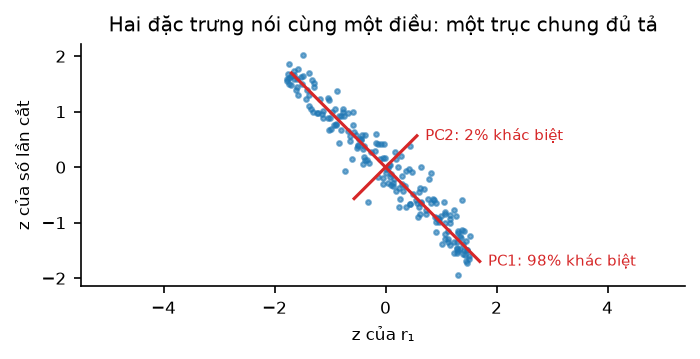

> **tune** · *hyperparameter tuning*
>
> - **Là gì:** thử nhiều cách đặt tham số của một mô hình, giữ cách cho sai số thấp nhất trên dữ liệu kiểm.
> - **Ví dụ:** thử 20 cách đặt cho mỗi chuỗi × 4.000 chuỗi = 80.000 lần khớp mô hình.
> - **Để làm gì:** tốn thời gian — nên dồn cho chuỗi còn cấu trúc để khai thác.

> **FFORMA** · *Feature-based FORecast Model Averaging*
>
> - **Là gì:** đưa bộ đặc trưng của chuỗi vào một mô hình để nó học cách trộn nhiều phương pháp dự báo cho từng chuỗi (Montero-Manso và cộng sự, 2020).
> - **Ví dụ:** chuỗi mùa vụ mạnh được trộn nặng về phương pháp mùa vụ; chuỗi gần nhiễu nặng về trung bình.
> - **Để làm gì:** dùng đặc trưng để **chọn** mô hình tự động; đứng thứ hai cuộc thi M4.

**Lý do.** Nhiều đặc trưng nói cùng một điều ($r_1$ cao thì số lần cắt trung bình thấp); PCA tìm trục chung đó. Nhưng phải chuẩn hoá từng
cột trước: không thì cột có số to (số lần cắt, hàng chục) lấn át cột số nhỏ ($r_1$, dưới 1) chỉ vì đơn vị.

**Kết quả.**

In [ ]:
cot = [c for c in bang.columns if bang[c].notna().all() and c not in ("trung_binh", "do_lech_chuan")
       and not c.startswith(("smape", "mase"))]             # chỉ đặc trưng, không lẫn cột sai số
pca = PCA(n_components=2, random_state=0)
toa_do = pca.fit_transform(StandardScaler().fit_transform(bang[cot]))
print("bỏ vì có NaN (chuỗi hằng):", [c for c in bang.columns[:20] if bang[c].isna().any()])
print(f"{len(cot)} đặc trưng | PC1 giữ {pca.explained_variance_ratio_[0]:.0%}, PC2 {pca.explained_variance_ratio_[1]:.0%}")
for k in (0, 1):
    nang = sorted(zip(cot, pca.components_[k], strict=True), key=lambda x: -abs(x[1]))[:4]
    print(f"PC{k + 1} nặng nhất:", ", ".join(f"{c} {w:+.2f}" for c, w in nang))

fig, truc = plt.subplots(1, 3, figsize=(11, 3))
for ax, c, ten in zip(truc, ["entropy_pho", "do_manh_mua_vu", "smape_snaive"], ["entropy", "độ mạnh mùa vụ F_S", "sMAPE (cắt ở 40%)"],
                      strict=True):
    h = ax.scatter(toa_do[:, 0], toa_do[:, 1], c=np.clip(bang[c], 0, 40), s=3, alpha=0.7)
    plt.colorbar(h, ax=ax, shrink=0.8)
    ax.set(title=ten, xlabel="PC1")
truc[0].set_ylabel("PC2")
plt.show()

nhom = np.where((bang["entropy_pho"] >= 0.666) & (bang["do_manh_mua_vu"] < 0.4), "dùng baseline", "đáng đầu tư mô hình")
print(bang.groupby(nhom)["smape_snaive"].agg(["size", "median"]).round(2).to_string())

PC1 (41%) đi từ chuỗi trơn (trái: $r_1$, tổng $r_k^2$ cao) sang chuỗi lởm chởm (phải: cắt trung bình nhiều); PC2 (15%) theo xu
hướng và mùa vụ. Vùng phải sáng ở ô entropy cũng sáng ở ô sMAPE và tối ở ô $F_S$. Ghép hai điều kiện — entropy ≥ 0,666 **và** $F_S$ < 0,4
— tách 137 chuỗi "dùng baseline" có sMAPE trung vị 18,11%, gấp ba nhóm 3.863 chuỗi còn lại (6,05%). Chỉ dùng entropy thì gạt nhầm cả
chuỗi entropy cao mà mùa vụ vẫn mạnh.

**Bài học.** Chuẩn hoá từng cột rồi PCA để thấy cả tập; dồn thời gian tune cho chuỗi còn cấu trúc. Đừng đọc khoảng cách trên bản đồ như
khoảng cách thật: hai trục chỉ giữ 56% khác biệt.

## 5. DTW so giá trị: không chuẩn hoá thì chỉ phân cụm theo độ lớn

**Vấn đề.** Muốn gom chuỗi cùng hình dạng (tăng đều, giảm dần, có bướu giữa…). Nhưng hai chuỗi cùng hình có thể lệch nhau một hai bước,
và khác nhau hẳn về độ lớn.

> **DTW (dynamic time warping)** · *dynamic time warping*
>
> - **Là gì:** khoảng cách giữa hai chuỗi cho phép co giãn trục thời gian để khớp đỉnh với đỉnh: $D(i,j) = (x_i - y_j)^2 + \min\{D(i-1,j), D(i,j-1), D(i-1,j-1)\}$, DTW $= \sqrt{D(n,n)}$.
> - **Ví dụ:** $x$ = 0, 0, 1, 0 và $y$ = 0, 1, 0, 0 (đỉnh sớm một bước): khoảng cách thường 1,41, DTW 0.
> - **Để làm gì:** gom các chuỗi cùng hình dạng dù đỉnh lệch nhau đôi chút (như Tết âm lịch năm sớm năm muộn).
>
> 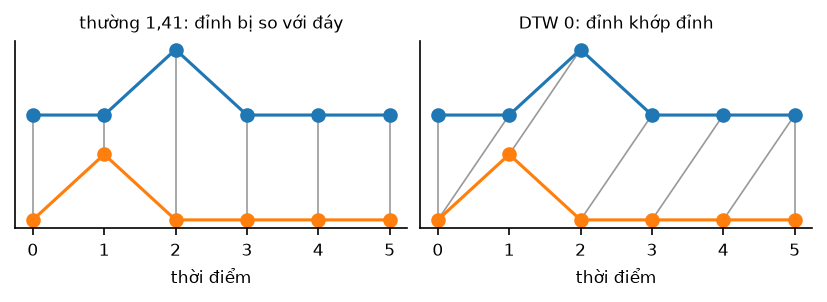

> **cửa sổ Sakoe–Chiba** · *Sakoe–Chiba band*
>
> - **Là gì:** giới hạn DTW chỉ được khớp lệch tối đa $w$ bước.
> - **Ví dụ:** $w$ = 10 tháng: tháng 1 không được khớp với tháng 11 của chuỗi kia.
> - **Để làm gì:** vừa nhanh hơn, vừa chặn những cách khớp vô lý.

> **phân cụm phân cấp Ward** · *Ward hierarchical clustering*
>
> - **Là gì:** bắt đầu mỗi chuỗi một nhóm, gộp dần hai nhóm gần nhau nhất (gộp mà độ phân tán trong nhóm tăng ít nhất) tới khi còn số nhóm muốn có.
> - **Ví dụ:** 300 chuỗi → gộp 296 lần → 4 cụm.
> - **Để làm gì:** nhóm chuỗi giống nhau để chọn cách dự báo cho từng nhóm.
>
> 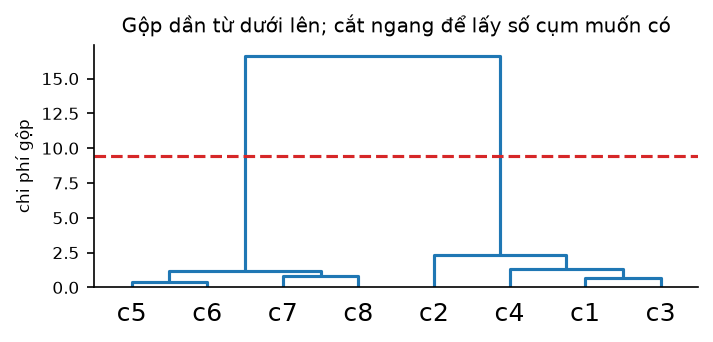

**Lý do.** DTW giải chuyện lệch thời gian, nhưng nó trừ **giá trị**: $z$ = 0, 3, 0, 0 cùng hình với $y$ mà DTW($x$, $z$) = 2. Phải z-score
từng chuỗi trước. Kiểm nhanh: nếu mức trung vị các cụm tăng đều theo số cụm thì bạn đang phân cụm theo độ lớn.

**Kết quả.**

In [ ]:
from dtaidistance import dtw
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import squareform


def dtw_tay(x, y):
    D = np.full((len(x) + 1, len(y) + 1), np.inf)
    D[0, 0] = 0
    for i in range(1, len(x) + 1):
        for j in range(1, len(y) + 1):
            D[i, j] = (x[i - 1] - y[j - 1]) ** 2 + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return np.sqrt(D[-1, -1])


def z(v):
    v = np.asarray(v, float)
    return (v - v.mean()) / v.std() if v.std() > 0 else v - v.mean()


x, y, z3 = np.array([0, 0, 1, 0.]), np.array([0, 1, 0, 0.]), np.array([0, 3, 0, 0.])
print(f"thường {np.linalg.norm(x - y):.2f} | DTW(x, y) {dtw_tay(x, y):.0f} | DTW(x, z) {dtw_tay(x, z3):.0f} | "
      f"DTW sau z-score {dtw_tay(z(x), z(z3)):.0f}")


def phan_cum(mau, chuan_hoa, so_cum=4, cua_so=10):
    day = [z(v) if chuan_hoa else np.asarray(v, float) for v in mau.values()]
    D = dtw.distance_matrix_fast(day, window=cua_so)
    D = np.where(np.isinf(D), 0, D)
    D = D + D.T
    return pd.Series(fcluster(linkage(squareform(D, checks=False), method="ward"), so_cum, criterion="maxclust"), index=list(mau))


mau = {t: chuoi[t] for t in list(chuoi)[:300]}
muc = pd.Series({t: v.mean() for t, v in mau.items()})
t0 = time.time()
cum = {ch: phan_cum(mau, ch) for ch in (False, True)}
print(f"300 chuỗi, hai lần phân cụm trong {time.time() - t0:.1f} giây")
for ch, nhan in cum.items():
    print("chuẩn hoá" if ch else "không chuẩn hoá", "— mức trung vị theo cụm:", muc.groupby(nhan).median().round(0).astype(int).to_dict())
dau = next(iter(mau))
print("nhân một chuỗi với 100, cụm giữ nguyên:", phan_cum({**mau, dau: 100 * mau[dau]}, True).equals(cum[True]))

fig, truc = plt.subplots(1, 4, figsize=(11, 2.4), sharey=True)
for ax, k in zip(truc, sorted(cum[True].unique()), strict=True):
    for t in cum[True][cum[True] == k].index[:12]:
        ax.plot(z(mau[t]), lw=0.7, alpha=0.5)
    ax.set_title(f"cụm {k} ({(cum[True] == k).sum()} chuỗi)", fontsize=9)
plt.show()

Không chuẩn hoá, mức trung vị tăng đều 1.585 → 3.310 → 6.835 → 9.832: thuật toán chỉ xếp chuỗi theo độ lớn, việc `sort()` làm được.
Chuẩn hoá thì mức lộn xộn (2.882, 4.891, 2.951, 4.164), và bốn cụm là bốn hình dạng; nhân một chuỗi với 100 không đổi cụm của nó.

**Bài học.** z-score trước DTW, giới hạn cửa sổ. Không dùng DTW khi chính thời điểm là điều cần phân biệt (đỉnh mùa đông khác đỉnh mùa
hè); nhớ chi phí tăng theo bình phương số chuỗi.

## 6. ABC nói sai ở đâu thì đắt; XYZ theo CV không đo độ khó

**Vấn đề.** Doanh nghiệp có hàng nghìn mã hàng và ít người. Cách phổ biến chia công sức: xếp mã theo giá trị (ABC) và theo dao động (XYZ),
coi CV nhỏ là "dễ", CV lớn là "khó".

> **phân loại ABC–XYZ (AX, CZ)** · *ABC–XYZ analysis*
>
> - **Là gì:** ABC xếp mã hàng theo doanh thu (A: 20% mã đầu, B: 30% tiếp, C: 50% còn lại); XYZ theo CV (X: CV < 0,5, Y: 0,5 … 1, Z: > 1). Ô AX là bán nhiều và đều; CZ là bán ít và thất thường.
> - **Ví dụ:** doanh thu 50, 25, 12, 8, 5 → mã đầu là A, mã thứ hai B, ba mã sau C.
> - **Để làm gì:** ABC cho biết sai ở đâu thì đắt, để chia công sức; XYZ theo CV **không** đo được độ khó dự báo.
>
> 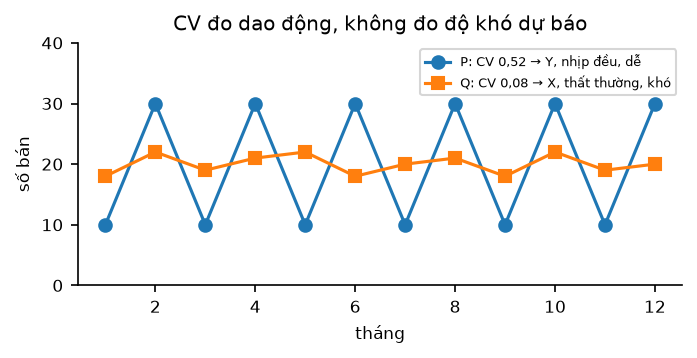

**Lý do.** Kourentzes (2016) phản bác trục XYZ. Mã $P$ bán 10, 30, 10, 30 có CV 0,58 (nhóm Y) nhưng lặp đúng mỗi 2 tháng — seasonal naive
không sai chút nào. Mã $Q$ bán 18, 22, 19, 21 có CV 0,09 (nhóm X) nhưng lên xuống không theo nhịp. CV đo dao động, không đo độ khó.

**Kết quả.** Online Retail II → doanh thu theo (mã hàng, tháng) → bảng ABC–XYZ (đọc Excel một triệu dòng mất một hai phút):

In [ ]:
with zipfile.ZipFile(lay("uci-online-retail-ii")) as zz:
    excel = io.BytesIO(zz.read("online_retail_II.xlsx"))
df = pd.concat([pd.read_excel(excel, sheet_name=s, usecols=["StockCode", "Quantity", "InvoiceDate", "Price"])
                for s in ("Year 2009-2010", "Year 2010-2011")], ignore_index=True)
df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]            # bỏ hoá đơn huỷ, trả hàng
df["doanh_thu"] = df["Quantity"] * df["Price"]
df["thang"] = pd.to_datetime(df["InvoiceDate"]).dt.to_period("M").dt.to_timestamp()
ban_le = df.assign(StockCode=df["StockCode"].astype(str)).groupby(["StockCode", "thang"], as_index=False)["doanh_thu"].sum()
del df, excel

h = ban_le.groupby("StockCode")["doanh_thu"].agg(["sum", "mean", "std", "count"])
h = h[h["count"] >= 12].sort_values("sum", ascending=False)       # ít nhất 12 tháng có doanh thu
h["cv"] = h["std"] / h["mean"]
ty_le = np.arange(1, len(h) + 1) / len(h)
h["abc"] = np.where(ty_le <= 0.2, "A", np.where(ty_le <= 0.5, "B", "C"))
h["xyz"] = np.where(h["cv"] < 0.5, "X", np.where(h["cv"] <= 1, "Y", "Z"))
print(f"{len(h):,} mã hàng | A mang {h.loc[h['abc'] == 'A', 'sum'].sum() / h['sum'].sum():.1%} doanh thu | "
      f"CV trung vị theo ABC: {h.groupby('abc')['cv'].median().round(2).to_dict()}")
print(h.groupby(["abc", "xyz"]).size().unstack(fill_value=0).to_string())

for ten, v in (("P", [10, 30, 10, 30]), ("Q", [18, 22, 19, 21])):
    print(f"mã {ten}: CV {np.std(v, ddof=1) / np.mean(v):.2f}")
cv = bang["he_so_bien_thien"]
print(f"M4: Spearman CV × sMAPE {stats.spearmanr(cv, bang['smape_snaive'])[0]:.3f} | "
      f"CV × MASE {stats.spearmanr(cv, bang['mase_snaive'], nan_policy='omit')[0]:.3f}")

2.773 mã hàng có ít nhất 12 tháng doanh thu; dòng A (một phần năm số mã) mang 74,7% doanh thu, và ô CZ đông gần gấp bốn ô AX. CV
trung vị tăng từ A sang C (0,63; 0,83; 0,92): mã bán ít thì bán thất thường hơn. Trên M4, CV và sMAPE có Spearman 0,765 — tương quan cao,
nhưng CV vẫn xếp sai đúng những chuỗi mùa vụ đều như mã $P$, là chuỗi đáng mô hình nhất.

**Bài học.** Dùng ABC để đặt công sức (ô A đáng mô hình tốt nhất và người xem lại hằng tuần). Thay trục XYZ bằng **sai số thật của một
baseline** trên kỳ chấm, như sMAPE ở phần 3.

## 7. Bài tập về nhà — đáp số

**Bài 1 — Entropy sau khử xu hướng.** Tính entropy trên phần dư STL (cùng STL như đặc trưng, trên chuỗi z-score):

In [ ]:
def entropy_phan_du(y):
    kq = STL(pd.Series(z(y), index=pd.period_range("2000-01", periods=y.size, freq="M").to_timestamp()), period=M).fit()
    return entropy_pho(kq.resid.to_numpy())


bang["entropy_phan_du"] = [entropy_phan_du(v[:-TAM]) for v in chuoi.values()]
print("khoảng giữa 50% của entropy — gốc:", bang["entropy_pho"].quantile([0.25, 0.75]).round(2).tolist(),
      "| phần dư:", bang["entropy_phan_du"].quantile([0.25, 0.75]).round(2).tolist())
for c in ("entropy_pho", "entropy_phan_du"):
    print(f"{c:<16} × sMAPE: Pearson {bang[c].corr(bang['smape_snaive']):+.3f}, "
          f"Spearman {stats.spearmanr(bang[c], bang['smape_snaive'])[0]:+.3f}")

Phần dư STL của chuỗi nào cũng gần nhiễu, nên entropy của nó dồn vào dải hẹp 0,73 … 0,83 (một nửa số chuỗi; chuỗi gốc: 0,31 … 0,63) và gần như mất khả năng phân biệt: tương quan
với sMAPE tụt từ +0,245 xuống +0,060. Xếp hạng độ khó thì dùng entropy **chuỗi gốc**; entropy phần dư chỉ để kiểm lại những chuỗi có xu
hướng mạnh mà entropy gốc thấp.

**Bài 2 — Skill score** của seasonal naive so với naive trên kỳ chấm: skill = 1 − MAE(seasonal naive) / MAE(naive).

In [ ]:
skill = {}
for ten, v in chuoi.items():
    hoc, kiem = v[:-TAM], v[-TAM:]
    mae_mv, mae_n = np.mean(np.abs(kiem - np.resize(hoc[-M:], TAM))), np.mean(np.abs(kiem - hoc[-1]))
    skill[ten] = 1 - mae_mv / mae_n if mae_n > 0 else np.nan
bang["skill"] = pd.Series(skill)
print(f"skill trung vị {bang['skill'].median():.3f}; tỷ lệ chuỗi seasonal naive hơn naive {(bang['skill'] > 0).mean():.1%}")
for c in ("entropy_pho", "do_manh_mua_vu"):
    print(f"skill × {c:<15} Spearman {stats.spearmanr(bang[c], bang['skill'], nan_policy='omit')[0]:+.3f}")

Seasonal naive chỉ hơn naive ở 39,2% số chuỗi (skill trung vị −0,143). Skill tăng theo $F_S$ (Spearman +0,336): mùa vụ mạnh thì lặp
mùa vụ có ích — đúng điều skill đo. Nhưng skill cũng là **tỷ số** hai sai số như MASE: chuỗi nhiễu làm cả hai phương pháp cùng sai, nên
skill trả lời "mùa vụ có giúp không", không trả lời "chuỗi khó cỡ nào" — cùng bài học phần 3.

**Bài 3 — Cụm và chiến lược.** sMAPE trung vị của seasonal naive trong từng cụm DTW (đã chuẩn hoá), so với nhãn entropy + $F_S$:

In [ ]:
n_ = pd.Series(nhom, index=bang.index)
bc = pd.DataFrame({"cum": cum[True], "smape": bang.loc[cum[True].index, "smape_snaive"],
                   "baseline": n_[cum[True].index] == "dùng baseline"})
print(bc.groupby("cum").agg(so_chuoi=("smape", "size"), smape_trung_vi=("smape", "median"), so_nhan_baseline=("baseline", "sum"))
      .round(2).to_string())

Cụm 3 (17 chuỗi) khó hẳn, sMAPE trung vị 14,89% — ứng viên dùng baseline. Nhưng 9 chuỗi mà entropy + $F_S$ gắn nhãn "dùng baseline"
nằm ở cụm 1 và 4, không chuỗi nào ở cụm 3: nhóm theo **hình dạng** không trùng nhóm theo **độ khó**. Dùng cụm để gợi ý, còn quyết định
thì dựa trên sai số baseline thật.

## Tự kiểm

- [ ] Nói được vì sao CV không đổi khi nhân chuỗi với 1.000, còn trung bình thì đổi.
- [ ] Tính spectral entropy của phổ hai tần số 0,9 và 0,1.
- [ ] Giải thích vì sao MASE của seasonal naive luôn quanh 1 và không đo được độ khó giữa các chuỗi.
- [ ] Giải thích vì sao phải chuẩn hoá từng cột trước PCA.
- [ ] Tính DTW của $x$ = 1, 3, 1 và $y$ = 1, 1, 3.
- [ ] Cho một ví dụ mã hàng nhóm Z mà dự báo rất dễ.